In [45]:
import pandas as pd
import datetime as datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

df = pd.read_csv('hourly_pm2.5_data.csv')

In [46]:
#merge the data and the time columns
df["date_time_merged"] = df["date_local"] + ' ' + df["time_local"]
#create a proper datetime column
df["date_time"] = pd.to_datetime(df["date_time_merged"])

In [ ]:
df["years"] = df["date_time"].dt.year
df["days"] = df["date_time"].dt.day
df["hours"] = df['date_time'].dt.hour
df["months"] = df['date_time'].dt.month
df["day of week"] = df['date_time'].dt.day_of_week
df["day of year"] = df['date_time'].dt.day_of_year

#set a start date so we can track days elapsed
start_date = df["date_time"].iloc[0]

df["date_time_elapsed"] = (df['date_time'] - start_date)

df["days_elapsed"] = df['date_time_elapsed'].dt.days

After adding a datetime column to our dataframe, we can now move onto grouping the measurements of PM 2.5 Concentration by Day. This will allow us to make keen extrapolations of the sample measurements by year, day of week, and by the season they are in.

In [ ]:
# df_by_day = df.groupby(pd.Grouper(key="date_time", freq= "D"))['sample_measurement'].mean() #measurements grouped by day
# df_by_day.head()



date_time
1999-01-01    21.6
1999-01-02    11.1
1999-01-03    15.0
1999-01-04     9.5
1999-01-05    14.7
Freq: D, Name: sample_measurement, dtype: float64

In [49]:
# fig1, ax1 = plt.subplots(figsize=(10,4))
# df_by_day.plot(df_by_day['date_time'], df_by_day['sample_measurement'], ax=ax1,)
# ax1.set_title("Salt Lake City PM 2.5 Concentrations by Day from 1999 to 2026")
# ax1.set_xlabel("Years")
# ax1.set_ylabel("PM 2.5 Concentrations (µg/m^3)")
# plt.show()
# plt.close()

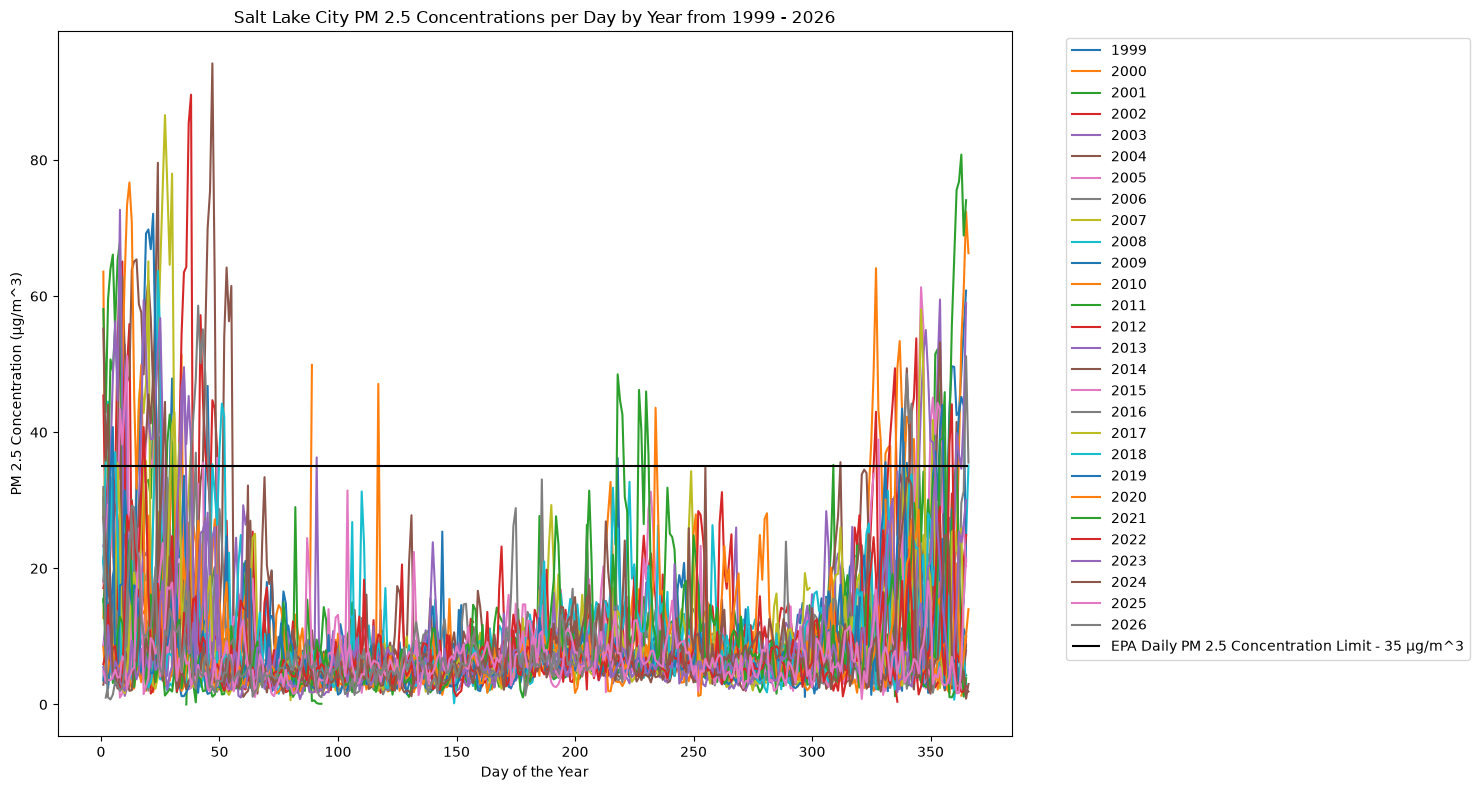

In [57]:
df_by_day = df.groupby(['years', 'day of year'])['sample_measurement'].mean()
df_by_day.head()

df_by_day_flatten = df_by_day.reset_index()
pivoted = df_by_day_flatten.pivot(index = 'day of year', columns = 'years', values='sample_measurement')
fig1, ax1 = plt.subplots(figsize=(15,8))
ax1.plot(pivoted, label = np.arange(1999,2027,1))
ax1.set_title("Salt Lake City PM 2.5 Concentrations per Day by Year from 1999 - 2026")
ax1.set_xlabel("Day of the Year")
ax1.set_ylabel("PM 2.5 Concentration (µg/m^3)")
plt.hlines(
    y=35, xmin = 0, xmax = 366, colors = "black",  label = "EPA Daily PM 2.5 Concentration Limit - 35 µg/m^3"
)
plt.legend(bbox_to_anchor=(1.05,1),loc='upper left')
plt.tight_layout()
plt.show()
# plt.close()

This graph plots daily PM 2.5 Concentrations against the Day of the Year that these concentrations were recorded in. Each line that is plotted represents a different year of data.

Text(0, 0.5, 'PM 2.5 Concentration (µg/m^3)')

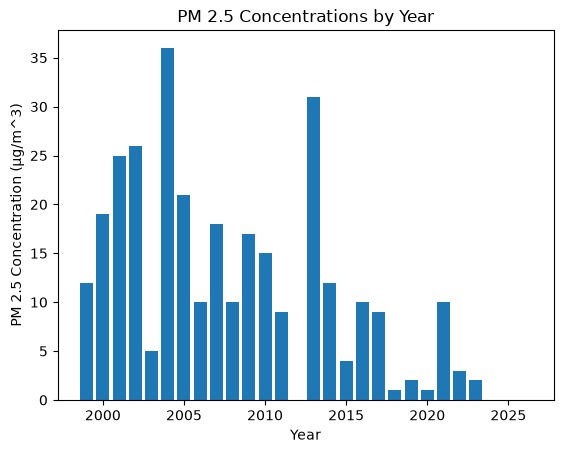

In [82]:
df_exceedance = df_by_day_flatten.groupby("years")["sample_measurement"].agg(lambda x: (x>35).sum())
df_exceedance
df_exceedance= pd.DataFrame(df_exceedance)
plt.bar(df_exceedance.index, df_exceedance["sample_measurement"])
plt.title("PM 2.5 Concentrations by Year")
plt.xlabel("Year")
plt.ylabel("PM 2.5 Concentration (µg/m^3)")

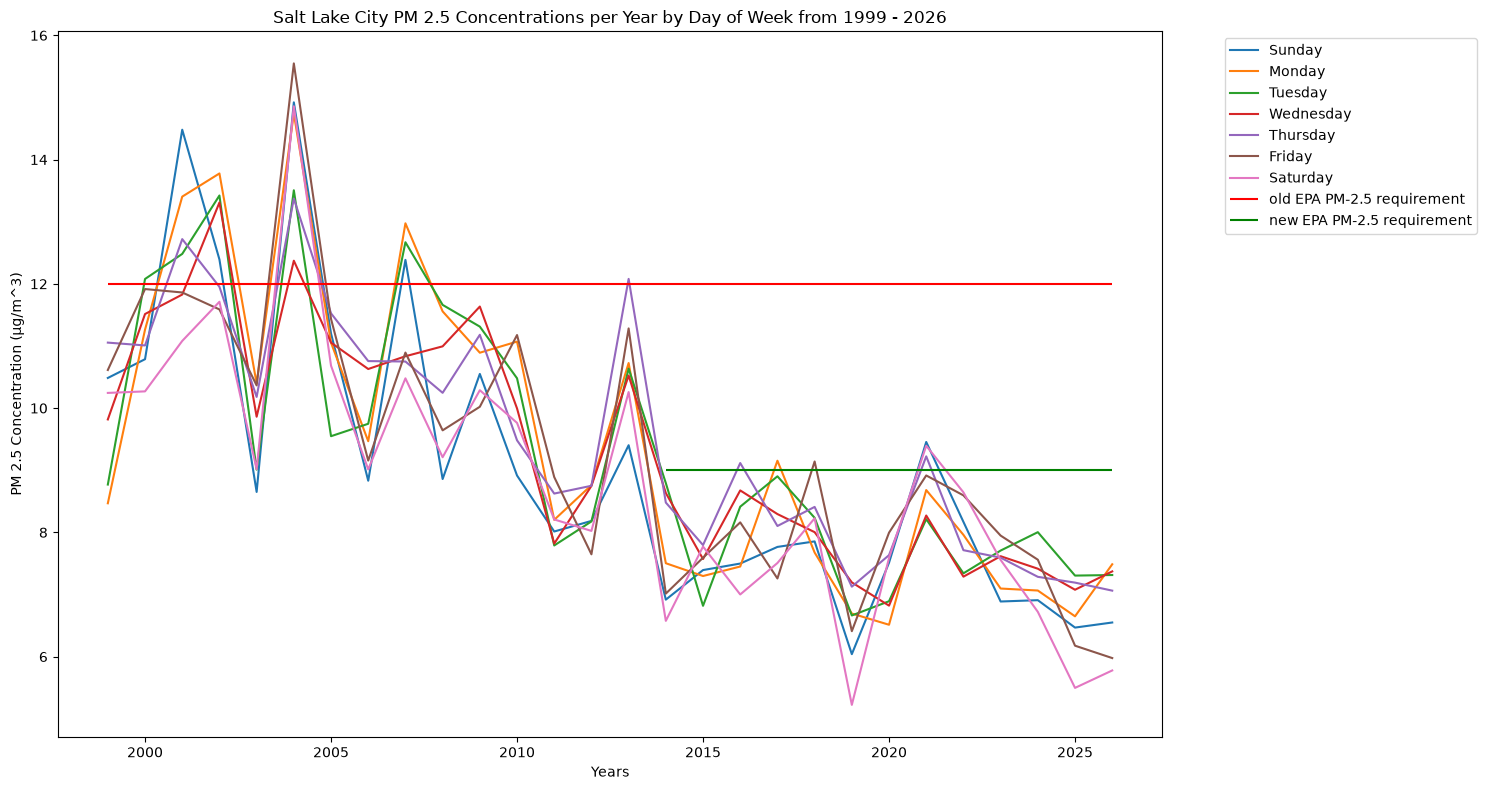

In [100]:
#now I will try to graph PM 2.5 concentrations by day of weak across all of our years. hourly will be tough to breach
df_by_dow = df.groupby(['years', 'day of week'])['sample_measurement'].mean()
df_by_dow.head()

df_by_dow_flat = df_by_dow.reset_index()
df_dow_pivoted = df_by_dow_flat.pivot(index = 'years', columns='day of week', values='sample_measurement')

fig2, ax2 = plt.subplots(figsize=(15,8))
ax2.plot(df_dow_pivoted, label = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"])
ax2.set_title("Salt Lake City PM 2.5 Concentrations per Year by Day of Week from 1999 - 2026")
ax2.set_xlabel("Years")
ax2.set_ylabel("PM 2.5 Concentration (µg/m^3)")
plt.hlines(
    y=12,xmin=1999, xmax=2026, colors="red", label= "old EPA PM-2.5 requirement"
)
plt.hlines(
    y=9, xmin=2014, xmax = 2026, colors = "green", label = "new EPA PM-2.5 requirement"
)
plt.legend(bbox_to_anchor=(1.05,1),loc='upper left')
plt.tight_layout()
plt.show()
plt.close()

#kind of useless?? bar chart would be better

In [79]:
df_dow = df.groupby(['day of week'],)['sample_measurement'].mean()
df_dow

day of week
0    7.530833
1    7.692486
2    7.922311
3    7.866394
4    8.137811
5    7.878053
6    7.421055
Name: sample_measurement, dtype: float64

<BarContainer object of 7 artists>

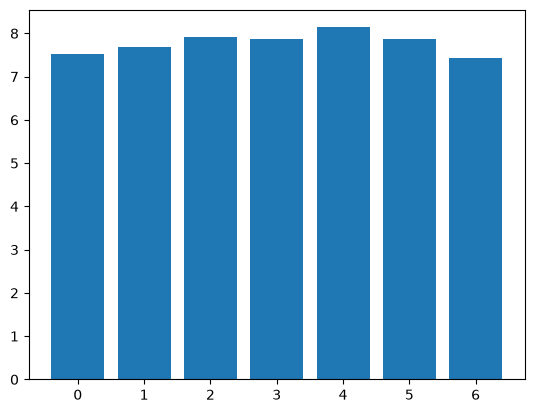

In [89]:
df_dow = df.groupby('day of week')['sample_measurement'].mean()
df_dow_flat = df_dow.reset_index()

plt.bar(df_dow_flat["day of week"], df_dow_flat["sample_measurement"])



In [ ]:

plt.bar(df_dow.index, df_dow['sample_measurement'])



plt.bar(df_exceedance.index, df_exceedance["sample_measurement"])
plt.title("PM 2.5 Concentrations by Year")
plt.xlabel("Year")
plt.ylabel("PM 2.5 Concentration (µg/m^3)")